# Full scikit-fair benchmark 
## Stratification on target and sensitive features

Runs the configuration in `config.yaml` through `Experiment.from_config()`.
All outputs (CSV, pickle, HTML report) are written to
`../../outputs/real_datasets/joint_stratification.{csv,pkl,html}` automatically
via the `save:` block of the YAML.


## The YAML configuration

In [ ]:
with open("config.yaml") as f:
    print(f.read())

## Run the experiment

`save.results_csv`, `save.object_pkl`, and `save.report_html` in the YAML are
all `true`, so results are persisted to
`../../outputs/real_datasets/joint_stratification.{csv,pkl,html}` as soon as
`run()` completes.



 -- First experiment - all metrics, all datasets, all models but OPP - simple preprocessing, all defaults

In [ ]:
from pathlib import Path
import yaml
from skfair.experimentation import Experiment

with open("config.yaml") as f:
    _cfg = yaml.safe_load(f)
Path(_cfg["save"]["path"]).parent.mkdir(parents=True, exist_ok=True)

exp = Experiment.from_config("config.yaml")
results = exp.run(verbose=True)
results

## Summary tables

`to_report()` wraps the results in a `ComparisonReport`. `summary_tables()`
returns one DataFrame per metric, averaged over classifiers by default.

In [3]:
report = exp.to_report()
tables = report.summary_tables()
for name, df in tables.items():
    print(f"--- {name} ---")
    display(df)

--- Adult ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.8492,0.7689,0.7232,0.6141,0.6630,0.3310,-0.1759,-0.0774,-0.0753,0.0731,0.2847,1.1353,0.8761,0.0774
DisparateImpactRemover,0.8489,0.7676,0.7246,0.6107,0.6614,0.3372,-0.1726,-0.0787,-0.0741,0.0696,0.3030,1.1323,0.8736,0.0787
FAWOS,0.8464,0.7752,0.7002,0.6378,0.6671,0.4877,-0.1366,0.0582,0.0066,0.0451,0.5895,1.1217,1.0935,-0.0582
FairBalanceClassifier,0.8205,0.8085,0.5980,0.7852,0.6769,0.4561,-0.2083,-0.0070,-0.0565,0.1060,0.4886,1.1200,0.9865,0.0070
FairMask,0.8497,0.7683,0.7260,0.6114,0.6627,0.3379,-0.1720,-0.0699,-0.0699,0.0700,0.2967,1.1342,0.8874,0.0699
FairOversampling,0.8232,0.8046,0.6058,0.7687,0.6758,0.4474,-0.2066,-0.0027,-0.0546,0.1064,0.4672,1.1274,0.9953,0.0027
FairSmote,0.8230,0.8057,0.6043,0.7724,0.6768,0.4584,-0.2039,0.0056,-0.0492,0.1040,0.4838,1.1250,1.0094,-0.0056
FairwayRemover,0.8482,0.7654,0.7251,0.6056,0.6583,0.3239,-0.1754,-0.0891,-0.0807,0.0722,0.2794,1.1348,0.8552,0.0891
HeterogeneousFOS,0.8237,0.7954,0.6149,0.7409,0.6693,0.4794,-0.1818,0.0082,-0.0370,0.0823,0.5332,1.1130,1.0075,-0.0082


--- Compas ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.6571,0.6444,0.6518,0.5160,0.5757,0.5467,-0.1784,-0.1842,-0.1535,0.1228,0.5050,1.0568,0.6696,0.1842
DisparateImpactRemover,0.6575,0.6455,0.6494,0.5234,0.5793,0.5868,-0.1643,-0.1651,-0.1382,0.1113,0.5556,1.0546,0.7076,0.1651
FAWOS,0.6541,0.6442,0.6357,0.5438,0.5860,0.8841,-0.0459,-0.0149,-0.0129,0.0109,0.9617,1.0387,0.9749,0.0149
FairBalanceClassifier,0.6477,0.6442,0.6099,0.6085,0.6088,0.8880,-0.0508,-0.0195,-0.0178,0.0160,0.9532,1.0186,0.9689,0.0195
FairMask,0.6518,0.6365,0.6570,0.4815,0.5551,0.6668,-0.1166,-0.1014,-0.0887,0.0760,0.6498,1.0705,0.7973,0.1014
FairOversampling,0.6504,0.6451,0.6160,0.5912,0.6023,0.8671,-0.0572,-0.0311,-0.0251,0.0191,0.9338,1.0210,0.9461,0.0311
FairSmote,0.6511,0.6454,0.6179,0.5880,0.6020,0.8727,-0.0564,-0.0226,-0.0227,0.0228,0.9252,1.0305,0.9655,0.0226
FairwayRemover,0.6520,0.6361,0.6612,0.4748,0.5512,0.5464,-0.1601,-0.1747,-0.1385,0.1022,0.5190,1.0545,0.6555,0.1747
HeterogeneousFOS,0.6498,0.6440,0.6166,0.5857,0.6003,0.8942,-0.0471,-0.0287,-0.0167,0.0046,0.9855,1.0096,0.9550,0.0287


--- German ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7288,0.6434,0.7788,0.8568,0.8143,0.8803,-0.0945,-0.0624,-0.0790,0.0956,0.8604,0.9431,0.9264,0.0624
DisparateImpactRemover,0.7290,0.6476,0.7820,0.8511,0.8133,0.8478,-0.1211,-0.0702,-0.1151,0.1600,0.7449,0.9659,0.9186,0.0702
FAWOS,0.7352,0.6421,0.7768,0.8750,0.8214,0.9351,-0.0519,-0.0322,-0.0300,0.0278,0.9685,0.9380,0.9631,0.0322
FairBalanceClassifier,0.7108,0.6746,0.8136,0.7650,0.7862,0.8988,-0.0734,-0.0437,-0.0493,0.0550,0.8866,0.9683,0.9517,0.0437
FairMask,0.7232,0.6366,0.7750,0.8532,0.8107,0.9328,-0.0518,-0.0312,-0.0315,0.0319,0.9703,0.9426,0.9615,0.0312
FairOversampling,0.7100,0.6840,0.8230,0.7489,0.7821,0.9334,-0.0476,-0.0126,-0.0240,0.0355,0.9070,0.9938,0.9915,0.0126
FairSmote,0.6975,0.6746,0.8183,0.7318,0.7710,0.9305,-0.0462,0.0013,-0.0315,0.0642,0.8376,1.0201,1.0053,-0.0013
FairwayRemover,0.7260,0.6326,0.7716,0.8661,0.8142,0.9753,-0.0194,-0.0111,0.0064,-0.0239,1.0520,0.9336,0.9873,0.0111
HeterogeneousFOS,0.6868,0.6643,0.8137,0.7204,0.7611,0.9582,-0.0303,0.0138,-0.0161,0.0460,0.8847,1.0264,1.0277,-0.0138


--- Heart Disease ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.7981,0.7962,0.8236,0.8133,0.8134,1.7073,0.3110,0.1528,0.1239,-0.0950,1.7235,1.1097,1.2189,-0.1528
DisparateImpactRemover,0.8056,0.8023,0.8240,0.8317,0.8246,1.7309,0.3256,0.1469,0.1472,-0.1475,2.0836,1.0953,1.2039,-0.1469
FAWOS,0.7981,0.7962,0.8236,0.8133,0.8134,1.7073,0.3110,0.1528,0.1239,-0.0950,1.7235,1.1097,1.2189,-0.1528
FairBalanceClassifier,0.7926,0.7898,0.8158,0.8150,0.8116,1.5169,0.2359,0.0748,0.0461,-0.0175,1.2585,1.0779,1.0987,-0.0748
FairMask,0.7981,0.7954,0.8196,0.8200,0.8151,1.5913,0.2702,0.1136,0.0768,-0.0400,1.4440,1.1075,1.1595,-0.1136
FairOversampling,0.7944,0.7933,0.8230,0.8033,0.8106,1.5300,0.2367,0.0819,0.0384,0.0050,1.2714,1.0794,1.1120,-0.0819
FairSmote,0.7861,0.7842,0.8129,0.8017,0.8039,1.5187,0.2393,0.0786,0.0568,-0.0350,1.2468,1.0704,1.1050,-0.0786
FairwayRemover,0.7944,0.7925,0.8221,0.8100,0.8128,1.6183,0.2805,0.1521,0.0761,0.0000,0.9938,1.1485,1.2133,-0.1521
HeterogeneousFOS,0.7889,0.7871,0.8147,0.8033,0.8056,1.5132,0.2285,0.0489,0.0519,-0.0550,1.5514,1.0375,1.0760,-0.0489


--- Ricci ---


,accuracy,balanced_accuracy,precision,recall,f1_score,disparate_impact,spd,eod,aod,true_negative_rate_difference,predictive_equality,accuracy_parity,equal_opportunity_ratio,false_negative_rate_difference
method,,,,,,,,,,,,,,
Baseline,0.8985,0.8980,0.8926,0.9068,0.8968,0.4435,-0.3692,-0.0778,-0.1371,0.1964,0.4077,1.0817,0.9224,0.0778
DisparateImpactRemover,0.8248,0.8227,0.8239,0.8205,0.8162,0.7151,-0.2200,0.0174,-0.0230,0.0633,0.4470,1.0546,1.0811,-0.0174
FAWOS,0.8581,0.8609,0.8308,0.9379,0.8712,0.5959,-0.2648,0.0167,-0.0451,0.1069,0.7446,1.0158,1.0230,-0.0167
FairBalanceClassifier,0.9050,0.9046,0.8962,0.9242,0.9051,0.5382,-0.2917,0.0354,-0.0435,0.1224,0.5405,1.0762,1.0421,-0.0354
FairMask,0.9134,0.9130,0.9071,0.9250,0.9127,0.4768,-0.3382,-0.0111,-0.0904,0.1698,0.4792,1.0939,0.9938,0.0111
FairOversampling,0.8793,0.8811,0.8534,0.9333,0.8844,0.5413,-0.3076,0.0000,-0.0773,0.1545,0.6952,1.0592,1.0063,-0.0000
FairSmote,0.8941,0.8942,0.8793,0.9242,0.8957,0.5477,-0.2932,0.0125,-0.0551,0.1226,0.4060,1.0634,1.0183,-0.0125
FairwayRemover,0.6304,0.6125,0.5414,0.3750,0.4102,0.6478,-0.0303,0.0806,0.0488,-0.0171,0.8595,1.3418,0.9240,-0.0806
HeterogeneousFOS,0.8963,0.8968,0.8777,0.9333,0.8991,0.5232,-0.3131,0.0000,-0.0740,0.1481,0.6512,1.0694,1.0063,-0.0000


## Tradeoff and ranking plots

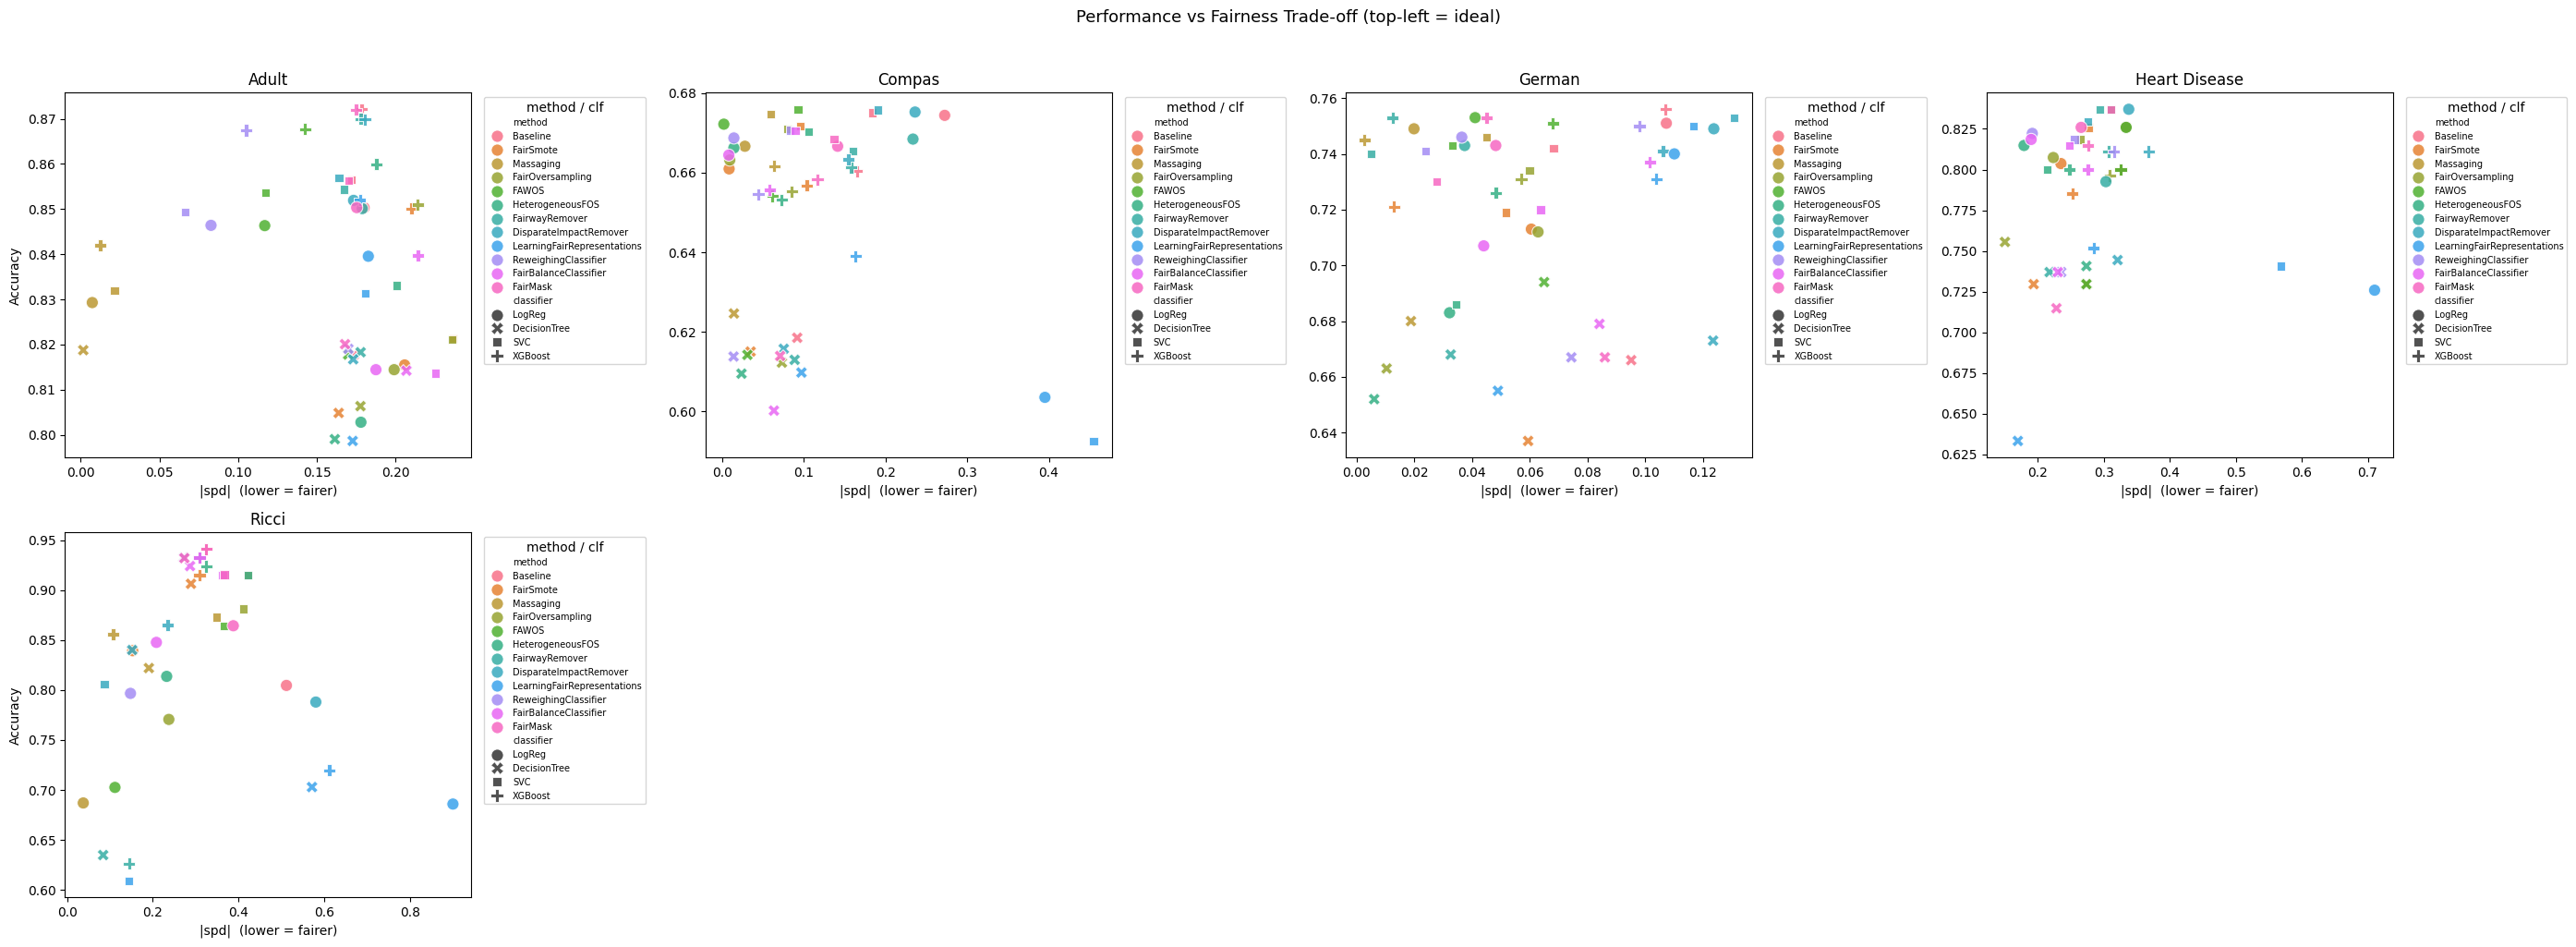

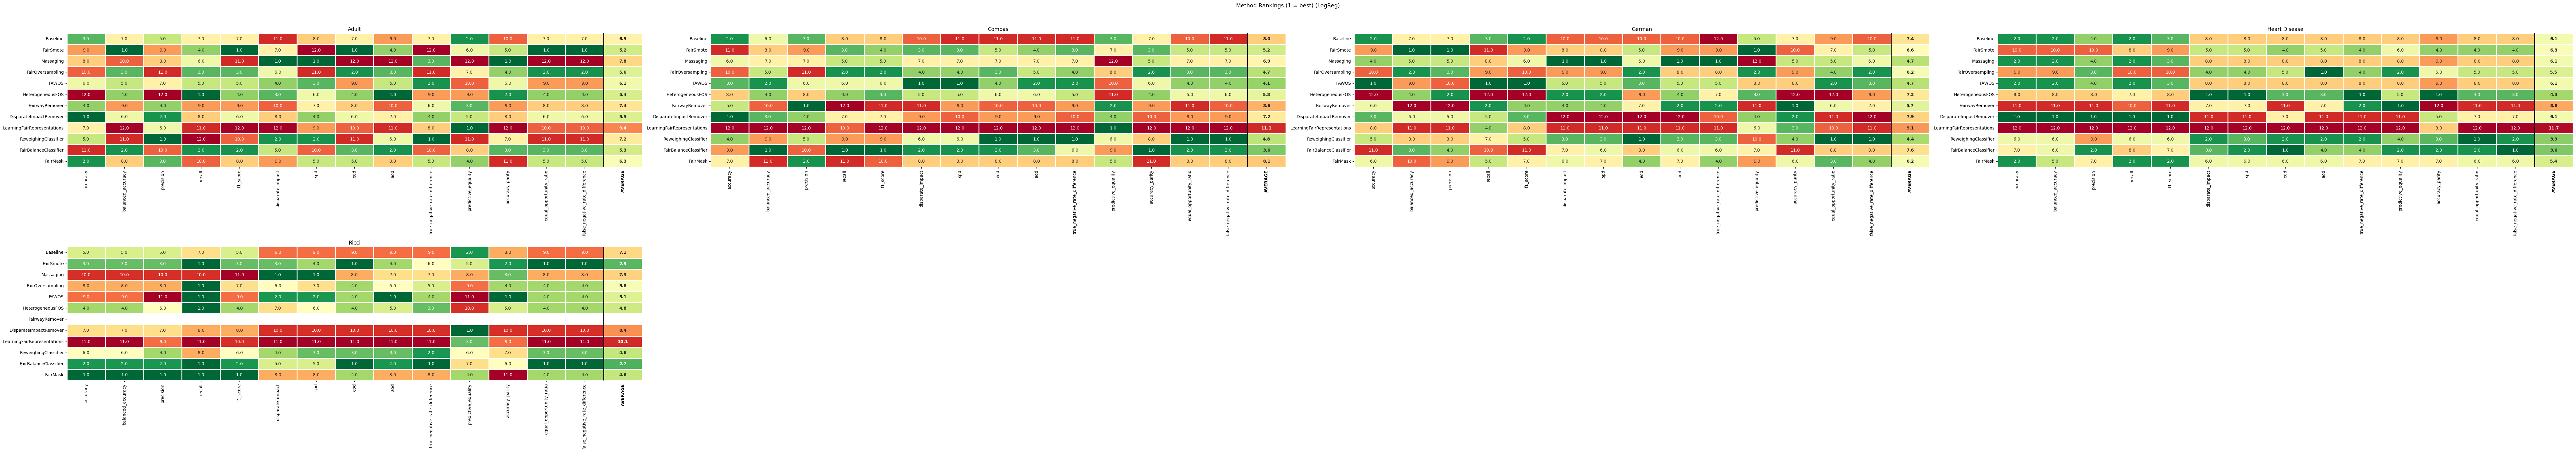

In [4]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");
report.plot_ranking(classifier="LogReg");